# 02 · Returns & Performance vs the Nifty 50

**Business question:** *Which stocks and sectors delivered the best returns over ~10 years, and did they beat the market?*

**Methods**
- Returns maths: simple vs log returns, **compounding**, **CAGR**, volatility drag
- Time-series analysis in pandas: cumulative growth, calendar-year returns, rolling windows

Run `python src/build_models.py` in the terminal before this notebook.

In [1]:
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

sys.path.append("../src")
from chart_style import apply_style, save, pct_axis, COLORS, PALETTE
apply_style()

con = duckdb.connect(str(Path("..") / "data" / "portfolio.duckdb"), read_only=True)
def sql(query):
    return con.sql(query).df()

BENCH = "Nifty 50 Index"

## 1. The cleaned data
`build_models.py` applied the data quality decisions from notebook 01 in SQL (`sql/staging/clean_prices.sql`): phantom holiday rows removed, one **common trading calendar** for every ticker,
and, in 2 cases where a single stock had no real price on a trading day, the previous price carried forward (flagged `is_filled`).

In [2]:
sql("""
    SELECT COUNT(DISTINCT date) AS trading_days, MIN(date) AS first_day, MAX(date) AS last_day,
           COUNT(DISTINCT ticker) AS tickers,
           SUM(CASE WHEN is_filled THEN 1 ELSE 0 END) AS carried_forward_prices
    FROM staging.clean_prices
""")

,trading_days,first_day,last_day,tickers,carried_forward_prices
0,2644,2016-01-04,2026-09-25,28,2.0


In [3]:
sql("SELECT * FROM marts.daily_returns WHERE ticker = 'TCS.NS' ORDER BY date DESC LIMIT 5")

,date,ticker,name,sector,close,daily_return,log_return
0,2026-09-25,TCS.NS,Tata Consultancy Services,IT,2082.000000,-0.002396,-0.002399
1,2026-09-24,TCS.NS,Tata Consultancy Services,IT,2087.000000,-0.001244,-0.001245
2,2026-09-23,TCS.NS,Tata Consultancy Services,IT,2089.600098,-0.007316,-0.007343
3,2026-09-22,TCS.NS,Tata Consultancy Services,IT,2105.000000,-0.011134,-0.011196
4,2026-09-21,TCS.NS,Tata Consultancy Services,IT,2128.699951,0.011259,0.011196


## 2. Returns maths
**Simple daily return** = today's close ÷ yesterday's close − 1. Returns **compound** (multiply), they don't add:

In [4]:
up_then_down = (1 + 0.50) * (1 - 0.50) - 1
print(f"+50% then -50% = {up_then_down:.0%}   (not 0%!)")

+50% then -50% = -25%   (not 0%!)


That's why you **can't just average returns**. The honest measure of long-run growth is the **CAGR** (Compound Annual Growth Rate):
the constant yearly rate that turns the starting value into the ending value.

$$\text{CAGR} = \left(\frac{\text{end value}}{\text{start value}}\right)^{1/\text{years}} - 1$$

In [5]:
prices  = sql("SELECT date, name, close FROM marts.daily_returns").pivot(index="date", columns="name", values="close")
returns = sql("SELECT date, name, daily_return FROM marts.daily_returns").pivot(index="date", columns="name", values="daily_return")
prices.index = pd.to_datetime(prices.index); returns.index = pd.to_datetime(returns.index)

years = (prices.index[-1] - prices.index[0]).days / 365.25
nifty = returns[BENCH].dropna()

arith = nifty.mean() * 252                                           # average daily return × 252 trading days
cagr  = (prices[BENCH].iloc[-1] / prices[BENCH].iloc[0]) ** (1 / years) - 1
print(f"Period: {prices.index[0].date()} → {prices.index[-1].date()}  ({years:.1f} years)")
print(f"Nifty 'average' annual return (arithmetic): {arith:.1%}")
print(f"Nifty CAGR (what an investor actually got): {cagr:.1%}")

Period: 2016-01-04 → 2026-09-25  (10.7 years)
Nifty 'average' annual return (arithmetic): 11.7%
Nifty CAGR (what an investor actually got): 10.7%


The simple average **overstates** the real growth by about 1 percentage point a year. The gap is called **volatility drag**: the more a price swings, the bigger the gap.
**Always use CAGR** for long-run performance.

*(Log returns, `ln(today / yesterday)`, are another format: they **add up** over time, which makes some maths easier. We store both.)*

## 3. CAGR of every stock vs the Nifty 50

16 of 27 stocks had a higher CAGR than the Nifty 50 (10.7%)


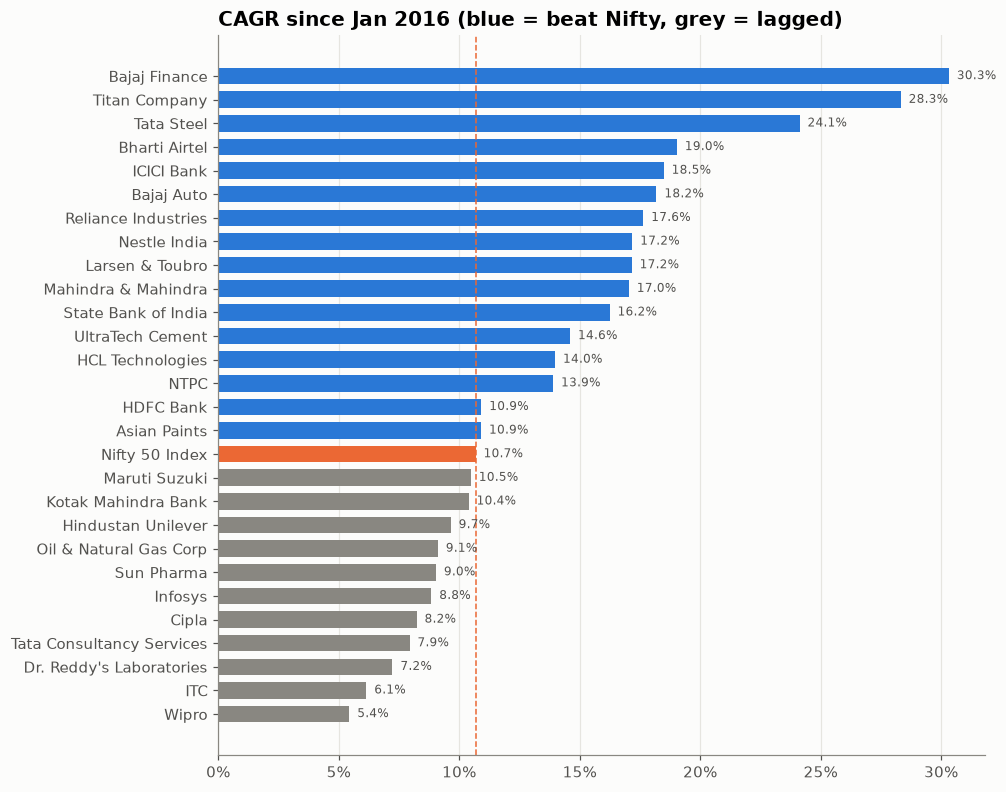

In [6]:
cagr_all = ((prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1).sort_values()
beat = (cagr_all.drop(BENCH) > cagr_all[BENCH])
print(f"{beat.sum()} of {len(beat)} stocks had a higher CAGR than the Nifty 50 ({cagr_all[BENCH]:.1%})")

fig, ax = plt.subplots(figsize=(9, 8.5))
colors = [COLORS["orange"] if n == BENCH else (COLORS["blue"] if v > cagr_all[BENCH] else COLORS["grey"])
          for n, v in cagr_all.items()]
ax.barh(cagr_all.index, cagr_all.values, color=colors, height=0.7)
ax.axvline(cagr_all[BENCH], color=COLORS["orange"], linestyle="--", linewidth=1)
for y, v in enumerate(cagr_all.values):
    ax.text(v, y, f"  {v:.1%}", va="center", fontsize=8, color="#52514e")
pct_axis(ax, axis="x")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("CAGR since Jan 2016 (blue = beat Nifty, grey = lagged)")
save(fig, "03_cagr_vs_nifty")
plt.show()

**Findings**
- The Nifty 50 compounded at **~10.7% a year**, turning ₹1 into ~₹3.
- Leaders: **Bajaj Finance (~30%)**, **Titan (~28%)** and **Tata Steel (~24%)**.
- Laggards: **Wipro, ITC, Dr. Reddy's and TCS** grew **slower than the index**, even though they're household names.
- The caveats from notebook 01 apply: survivorship bias, and the Nifty excludes dividends, so "beating the index" is flattered here.

## 4. Year by year: a returns heatmap
CAGR hides the ride. A **calendar-year heatmap** shows each stock's return in every year. Colours: **blue = gain, orange = loss**,
grey near zero (a *diverging* palette, because the data has a meaningful midpoint: 0%).

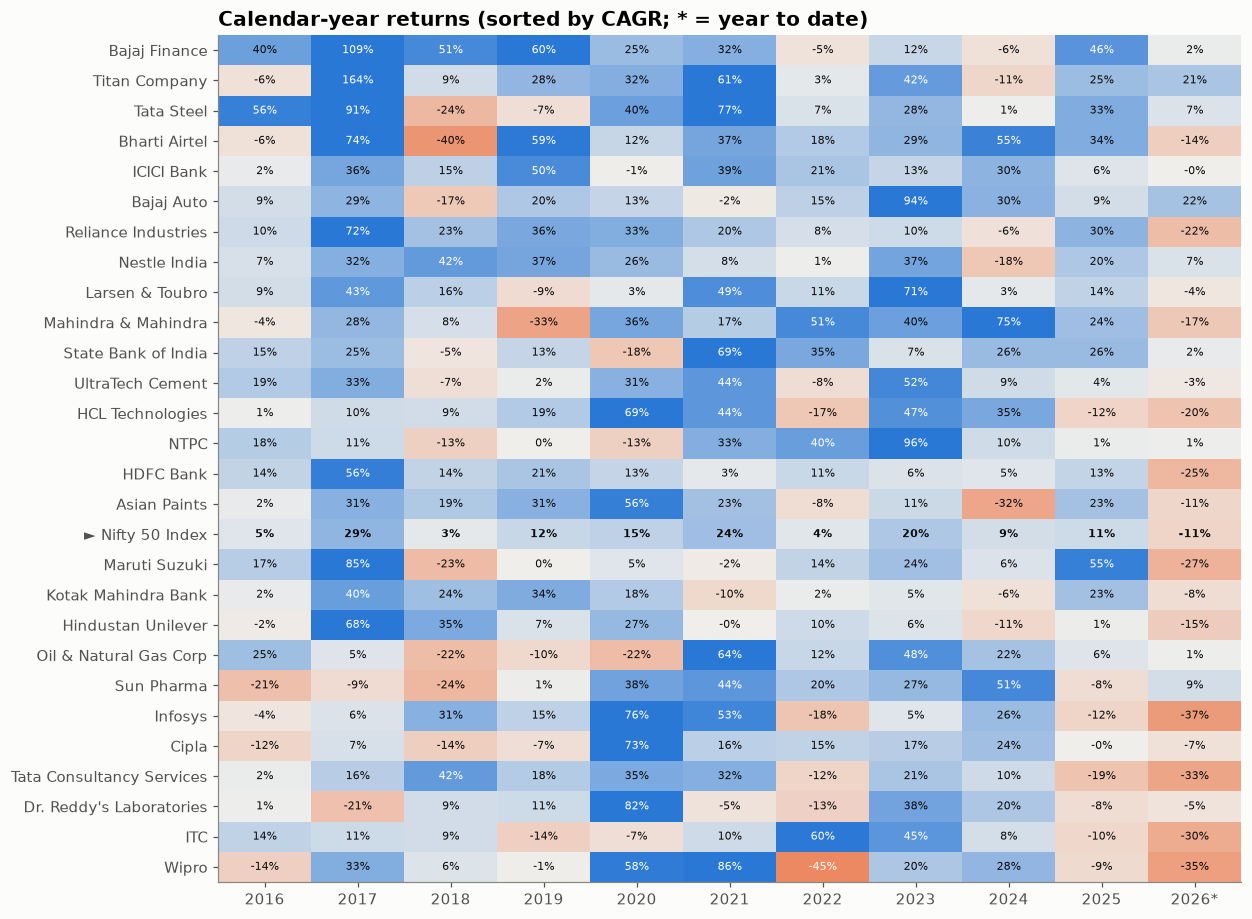

In [7]:
annual = sql("SELECT name, year, annual_return, is_partial_year FROM marts.annual_returns")
grid = annual.pivot(index="name", columns="year", values="annual_return")
grid = grid.loc[cagr_all.sort_values(ascending=False).index]            # sort rows by CAGR
partial_years = annual.loc[annual.is_partial_year, "year"].unique()
grid.columns = [f"{y}*" if y in partial_years else str(y) for y in grid.columns]

cmap = LinearSegmentedColormap.from_list("div", [COLORS["orange"], "#f0efec", COLORS["blue"]])
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(grid.values, cmap=cmap, norm=TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6), aspect="auto")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.iloc[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > 0.4 else "#0b0b0b",
                fontweight="bold" if grid.index[i] == BENCH else "normal")
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0]))
ax.set_yticklabels([f"► {n}" if n == BENCH else n for n in grid.index])
ax.grid(False)
ax.set_title("Calendar-year returns (sorted by CAGR; * = year to date)")
save(fig, "04_annual_returns_heatmap")
plt.show()

In [8]:
nifty_years = grid.loc[BENCH]
full_years = [c for c in grid.columns if not c.endswith("*")]
beat_count = (grid[full_years].drop(BENCH).gt(nifty_years[full_years], axis=1)).sum(axis=1).sort_values(ascending=False)
print(f"Nifty best year: {nifty_years.idxmax()} ({nifty_years.max():.0%}) · worst full year: "
      f"{nifty_years[full_years].idxmin()} ({nifty_years[full_years].min():.0%})")
print(f"\nYears each stock beat the Nifty (out of {len(full_years)} full years):")
beat_count.head(5).to_frame("years beating Nifty")

Nifty best year: 2017 (29%) · worst full year: 2018 (3%)

Years each stock beat the Nifty (out of 10 full years):


,years beating Nifty
name,
Bajaj Finance,7
Tata Steel,7
Bharti Airtel,7
Reliance Industries,7
Nestle India,7


**Findings**
- The Nifty was **positive in every full calendar year** from 2016 to 2025 (best: 2017, ~+29%), but **2026 so far is down ~11%**.
- Even strong long-run stocks had **brutal years**: Bharti Airtel −40% (2018), Tata Steel −24% (2018), Wipro −45% (2022). High CAGR doesn't mean a smooth ride.
- 2026 year-to-date is rough for **IT** (TCS −33%, Infosys −37%, Wipro −35%) and HDFC Bank (−25%).
- No stock beats the index every year. Consistency is rare, which is the core argument for **diversification** (notebook 04).

## 5. Sector performance
A **sector index** here = the equal-weighted average daily return of our stocks in that sector, compounded over time.

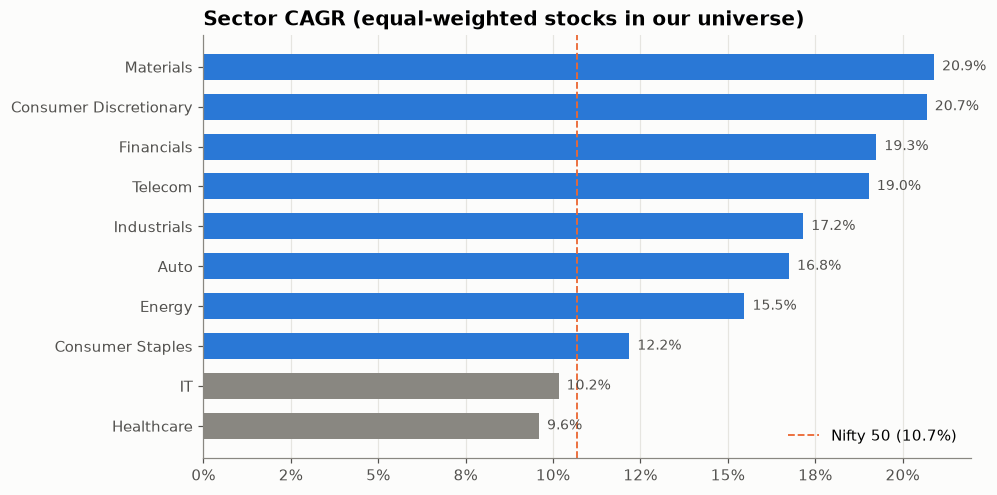

In [9]:
daily = sql("SELECT date, sector, daily_return FROM marts.daily_returns WHERE ticker <> '^NSEI'")
daily["date"] = pd.to_datetime(daily["date"])
sector_ret = daily.groupby(["date", "sector"])["daily_return"].mean().unstack().fillna(0)   # one column per sector
sector_growth = (1 + sector_ret).cumprod()                                                  # growth of ₹1
sector_cagr = (sector_growth.iloc[-1] ** (1 / years) - 1).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sector_cagr.index, sector_cagr.values,
        color=[COLORS["blue"] if v > cagr_all[BENCH] else COLORS["grey"] for v in sector_cagr.values], height=0.65)
ax.axvline(cagr_all[BENCH], color=COLORS["orange"], linestyle="--", linewidth=1.2, label=f"Nifty 50 ({cagr_all[BENCH]:.1%})")
for y, v in enumerate(sector_cagr.values):
    ax.text(v, y, f"  {v:.1%}", va="center", fontsize=9, color="#52514e")
pct_axis(ax, axis="x"); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Sector CAGR (equal-weighted stocks in our universe)")
ax.legend(loc="lower right")
save(fig, "05_sector_cagr")
plt.show()

**Findings:** **Materials, consumer discretionary and financials** led (~19–21% a year), while **IT and healthcare** (~10%) lagged the index.
IT is surprising for India's famous export sector: strong in 2020–21, then flat for years.
*(With only 1–5 stocks per sector these are indicative, not official sector indices.)*

## 6. A simple diversified portfolio vs the Nifty
What if you had put equal money in **all 27 stocks**? `(1 + r).cumprod()` turns daily returns into the growth of ₹1 over time.
*(Assumption: the portfolio is rebalanced back to equal weights daily, with no trading costs. We make this more realistic later.)*

Equal-weight 27 stocks    16.9%
Nifty 50                  10.7%
Name: 2026-09-25 00:00:00, dtype: str


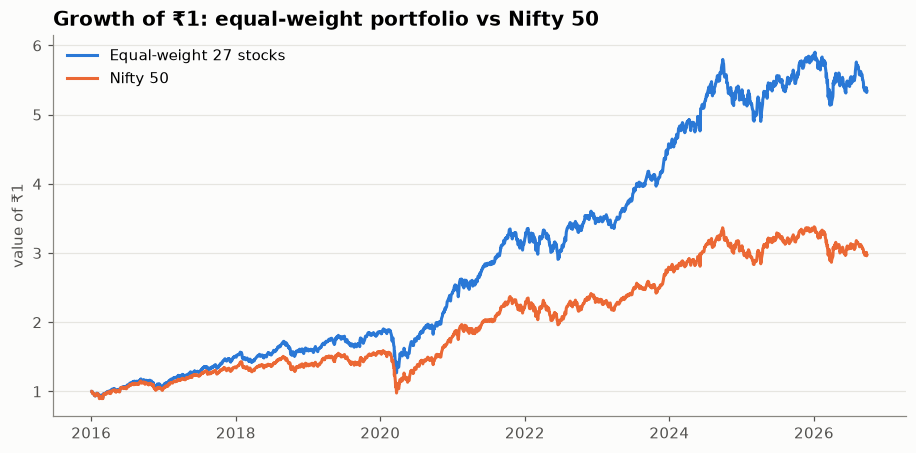

In [10]:
equal_weight = returns.drop(columns=BENCH).mean(axis=1).fillna(0)
growth = pd.DataFrame({
    "Equal-weight 27 stocks": (1 + equal_weight).cumprod(),
    "Nifty 50": (1 + returns[BENCH].fillna(0)).cumprod(),
})
ew_cagr = growth.iloc[-1] ** (1 / years) - 1
print(ew_cagr.map("{:.1%}".format))

fig, ax = plt.subplots()
ax.plot(growth.index, growth["Equal-weight 27 stocks"], color=COLORS["blue"], label="Equal-weight 27 stocks")
ax.plot(growth.index, growth["Nifty 50"], color=COLORS["orange"], label="Nifty 50")
ax.set_title("Growth of ₹1: equal-weight portfolio vs Nifty 50")
ax.set_ylabel("value of ₹1")
ax.legend(loc="upper left")
save(fig, "06_equal_weight_vs_nifty")
plt.show()

### Rolling 1-year returns
A **rolling window** recalculates a metric over the last N days, for every day. The 1-year return on each date = growth over the previous 252 trading days.
It shows how returns felt to an investor at any point in time, rather than one number for the whole decade.

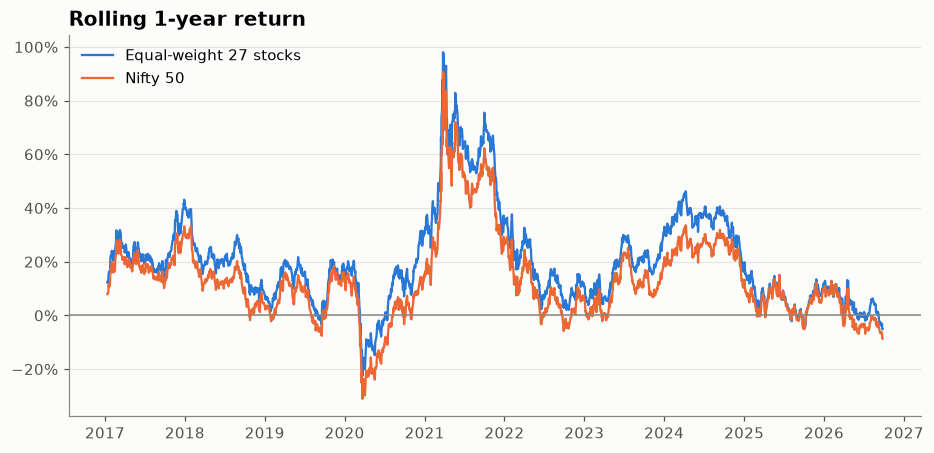

Share of days where the trailing 1-year return was positive:
Equal-weight 27 stocks    93%
Nifty 50                  85%
dtype: str


In [11]:
rolling_1y = growth / growth.shift(252) - 1        # shift(252) = value 252 trading days earlier

fig, ax = plt.subplots()
ax.plot(rolling_1y.index, rolling_1y["Equal-weight 27 stocks"], color=COLORS["blue"], label="Equal-weight 27 stocks", linewidth=1.5)
ax.plot(rolling_1y.index, rolling_1y["Nifty 50"], color=COLORS["orange"], label="Nifty 50", linewidth=1.5)
ax.axhline(0, color=COLORS["grey"], linewidth=1)
pct_axis(ax)
ax.set_title("Rolling 1-year return")
ax.legend(loc="upper left")
save(fig, "07_rolling_1y_return")
plt.show()

share_positive = (rolling_1y.dropna() > 0).mean()
print("Share of days where the trailing 1-year return was positive:")
print(share_positive.map("{:.0%}".format))

**Findings**
- An equal-weight portfolio of our 27 stocks compounded at **~17% a year vs ~10.7%** for the Nifty. That looks great, but a lot of it is **survivorship bias** (we chose today's winners) plus dividends.
- The rolling chart shows the **COVID crash** (trailing 1-year returns fell to about −20% to −30% in early 2020), a sharp rebound to +80–90% in early 2021, and **weakness again in 2026**.
- A 1-year holding was positive on ~85% of days for the Nifty (~93% for the equal-weight portfolio), so losses were possible, which leads to the **risk** analysis in notebook 03.

---
## Summary: key findings (Returns)
| # | Finding | So what? |
|---|---|---|
| 1 | Nifty 50 CAGR **~10.7%** (₹1 → ~₹3) since Jan 2016; arithmetic average overstates it by ~1 pt (volatility drag) | Always judge long-run returns by CAGR |
| 2 | 16 of 27 stocks beat the index; leaders Bajaj Finance (~30%), Titan (~28%), Tata Steel (~24%) | Big dispersion between winners and losers |
| 3 | Household names like **TCS, Infosys, ITC and Wipro lagged** the index | Size and fame ≠ returns |
| 4 | Materials, consumer discretionary and financials led; **IT and healthcare lagged** (~10%) | Sector choice mattered a lot |
| 5 | Nifty was positive in every full year 2016–2025, but **−11% YTD in 2026**; every stock had painful years | Returns are never smooth, so risk needs measuring |
| 6 | Equal-weight portfolio ~17% CAGR vs ~10.7% Nifty, **heavily flattered by survivorship bias** | Needs an honest out-of-sample test (notebook 04) |

Next: notebook 03 measures **risk**: volatility, drawdowns, beta, Value at Risk, Sharpe ratio, and the COVID crash.

In [12]:
con.close()